[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tviskaron/SB-RL-2026/blob/main/seminars/06-seminar-ppo.ipynb)

# Proximal Policy Optimization 

В практической реализации существует два варианта реализации алгоритма PPO:
* выполняет обновление, ограниченное KL, как TRPO, но штрафует KL-расхождение в целевой функции вместо того, чтобы делать его жестким ограничением, и автоматически регулирует коэффициент штрафа в процессе обучения, чтобы он масштабировался соответствующим образом.
* не содержит в целевой функции члена KL-дивергенции и вообще не имеет ограничения. Вместо этого полагается на специализированный клиппинг 

<img src="https://spinningup.openai.com/en/latest/_images/math/e62a8971472597f4b014c2da064f636ffe365ba3.svg">

Спойлер: клиппинг - не самое главное в PPO, как это могло показаться на первый взгляд. Алгоритм PPO работает во многом и за счет небольших дополнительных улучшений. Подробнее: https://arxiv.org/pdf/2005.12729.pdf

## Полистайте на досуге:
https://iclr-blog-track.github.io/2022/03/25/ppo-implementation-details/

<iframe src="https://iclr-blog-track.github.io/2022/03/25/ppo-implementation-details/" 
        width="100%" 
        height="600px" 
        style="border: none;">
</iframe>


In [17]:
try:
    import google.colab
    COLAB = True
except ModuleNotFoundError:
    COLAB = False
    pass

if COLAB:
    !apt -qq update -y
    !apt -qq install swig -y
    !pip -q install box2d-py
    !pip -q install "gymnasium[classic-control, box2d, atari, accept-rom-license]"
    !pip -q install piglet
    !pip -q install imageio_ffmpeg
    !pip -q install moviepy==1.0.3
    !pip install swig
    !pip install "gymnasium[box2d]"

# Вспомогатеьный код для визуализации

In [18]:
import gymnasium as gym
import numpy as np
import torch

from IPython.display import HTML
from base64 import b64encode
from gymnasium.wrappers import RecordVideo

import matplotlib.pyplot as plt
import glob
import os

%matplotlib inline


def show_video(video_path):
    """
    Показывает последнее записанное .mp4 видео из директории.
    """
    video_files = glob.glob(
        os.path.join(video_path, "*.mp4")
    )

    if not video_files:
        print(f"No video files found in {video_path}")
        return None

    latest_video = max(
        video_files,
        key=os.path.getctime,
    )

    with open(latest_video, "rb") as f:
        video_data = f.read()

    video_base64 = b64encode(
        video_data
    ).decode()

    return HTML(
        f"""
        <video width="640" controls>
            <source
                src="data:video/mp4;base64,{video_base64}"
                type="video/mp4"
            >
        </video>
        """
    )


def visualize_ppo_policy(
    ppo,
    env_name,
    num_episodes=3,
    video_path=None,
    deterministic=True,
    seed=None,
):
    """
    Запускает обученную PPO policy в любой Gymnasium-среде
    с Discrete action space, записывает эпизоды на видео
    и показывает статистику.

    Parameters
    ----------
    ppo:
        Обученный PPO agent.

    env_name:
        Gymnasium environment, например:
            "CartPole-v1"
            "MountainCar-v0"
            "LunarLander-v3"

    num_episodes:
        Количество evaluation episodes.

    video_path:
        Директория для видео.
        Если None, создаётся автоматически:
            videos/<env_name>/

    deterministic:
        True:
            a = argmax pi(a|s)
        False:
            a ~ pi(a|s)

    seed:
        Seed evaluation.
    """

    # ============================================================
    # Video directory
    # ============================================================

    if video_path is None:
        video_path = os.path.join(
            "videos",
            env_name,
        )

    os.makedirs(
        video_path,
        exist_ok=True,
    )

    # ============================================================
    # Environment
    # ============================================================

    env = gym.make(
        env_name,
        render_mode="rgb_array",
    )

    # Данная реализация PPO использует Categorical policy
    if not isinstance(
        env.action_space,
        gym.spaces.Discrete,
    ):
        env.close()

        raise ValueError(
            "visualize_ppo_policy currently expects "
            "a Discrete action space because the PPO actor "
            "uses Categorical(logits=...)."
        )

    env = RecordVideo(
        env,
        video_folder=video_path,
        episode_trigger=lambda episode_id: True,
        name_prefix="ppo-eval",
    )

    # ============================================================
    # Evaluation
    # ============================================================

    policy = ppo.policy_old
    policy.eval()

    episode_rewards = []
    episode_lengths = []

    for i_episode in range(num_episodes):

        episode_seed = (
            None
            if seed is None
            else seed + i_episode
        )

        state, _ = env.reset(
            seed=episode_seed
        )

        terminated = False
        truncated = False

        total_reward = 0.0
        steps = 0

        while not (
            terminated or truncated
        ):

            state_tensor = torch.as_tensor(
                state,
                dtype=torch.float32,
                device=device,
            )

            with torch.no_grad():

                action_logits = (
                    policy.action_layer(
                        state_tensor
                    )
                )

                if deterministic:
                    # Greedy evaluation
                    action = (
                        torch.argmax(
                            action_logits,
                            dim=-1,
                        )
                        .item()
                    )

                else:
                    # Stochastic evaluation
                    dist = (
                        torch.distributions
                        .Categorical(
                            logits=action_logits
                        )
                    )

                    action = (
                        dist.sample()
                        .item()
                    )

            (
                state,
                reward,
                terminated,
                truncated,
                _,
            ) = env.step(action)

            total_reward += reward
            steps += 1

        episode_rewards.append(
            total_reward
        )

        episode_lengths.append(
            steps
        )

        print(
            f"Episode {i_episode + 1}: "
            f"return = {total_reward:.1f}, "
            f"length = {steps}"
        )

    env.close()

    # ============================================================
    # Summary
    # ============================================================

    rewards = np.asarray(
        episode_rewards
    )

    lengths = np.asarray(
        episode_lengths
    )

    print(
        f"\nEnvironment: {env_name}"
    )

    print(
        f"Policy: "
        f"{'deterministic' if deterministic else 'stochastic'}"
    )

    print(
        f"Mean return: "
        f"{rewards.mean():.2f} "
        f"± {rewards.std():.2f}"
    )

    print(
        f"Mean episode length: "
        f"{lengths.mean():.1f} "
        f"± {lengths.std():.1f}"
    )

    # ============================================================
    # Plots
    # ============================================================

    episodes = np.arange(
        1,
        num_episodes + 1,
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4),
    )

    axes[0].bar(
        episodes,
        rewards,
    )

    axes[0].axhline(
        rewards.mean(),
        linestyle="--",
        label=f"mean = {rewards.mean():.1f}",
    )

    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Return")
    axes[0].set_title(
        f"{env_name}: episode return"
    )
    axes[0].legend()
    axes[0].grid(
        axis="y",
        alpha=0.2,
    )

    axes[1].bar(
        episodes,
        lengths,
    )

    axes[1].axhline(
        lengths.mean(),
        linestyle="--",
        label=f"mean = {lengths.mean():.1f}",
    )

    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Steps")
    axes[1].set_title(
        f"{env_name}: episode length"
    )
    axes[1].legend()
    axes[1].grid(
        axis="y",
        alpha=0.2,
    )

    plt.tight_layout()
    plt.show()

    return show_video(
        video_path
    )

In [19]:
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import torch


class LivePPODashboard:
    def __init__(
        self,
        ppo,
        env_name,
        refresh_every=10,
        ma_window=100,
        grid_size=50,
    ):
        self.ppo = ppo
        self.env_name = env_name
        self.refresh_every = refresh_every
        self.ma_window = ma_window
        self.grid_size = grid_size

        self.episodes = []
        self.returns = []
        self.lengths = []

        self.updates = []
        self.metrics = {
            "policy_loss": [],
            "value_loss": [],
            "entropy": [],
            "clip_fraction": [],
            "approx_kl": [],
        }

        self.display_handle = None

    # ============================================================
    # Logging
    # ============================================================

    def log_episode(self, episode, episode_return, length):
        self.episodes.append(episode)
        self.returns.append(episode_return)
        self.lengths.append(length)

        if episode == 1 or episode % self.refresh_every == 0:
            self.render()

    def log_update(self, stats):
        self.updates.append(len(self.updates) + 1)

        for k in self.metrics:
            self.metrics[k].append(stats[k])

    # ============================================================
    # Moving average
    # ============================================================

    def _ma(self, x):
        if len(x) < self.ma_window:
            return None, None

        y = np.convolve(
            x,
            np.ones(self.ma_window) / self.ma_window,
            mode="valid",
        )

        xs = np.asarray(self.episodes)[self.ma_window - 1:]

        return xs, y

    # ============================================================
    # Environment-specific 2D state slice
    # ============================================================

    def _grid_spec(self):
        """
        Возвращает:
            x values
            y values
            state_builder(X, Y)
            x label
            y label
            action names
        """

        n = self.grid_size

        # --------------------------------------------------------
        # CartPole
        #
        # state =
        # [cart_position,
        #  cart_velocity,
        #  pole_angle,
        #  pole_angular_velocity]
        # --------------------------------------------------------

        if self.env_name == "CartPole-v1":

            x = np.linspace(-0.21, 0.21, n)
            y = np.linspace(-4.0, 4.0, n)

            X, Y = np.meshgrid(x, y)

            states = np.stack(
                [
                    np.zeros_like(X),  # cart position
                    np.zeros_like(X),  # cart velocity
                    X,                 # pole angle
                    Y,                 # pole angular velocity
                ],
                axis=-1,
            )

            action_names = [
                "Left",
                "Right",
            ]

            return (
                X,
                Y,
                states,
                "Pole angle",
                "Pole angular velocity",
                action_names,
            )

        # --------------------------------------------------------
        # MountainCar
        #
        # state =
        # [position,
        #  velocity]
        # --------------------------------------------------------

        elif self.env_name == "MountainCar-v0":

            x = np.linspace(-1.2, 0.6, n)
            y = np.linspace(-0.07, 0.07, n)

            X, Y = np.meshgrid(x, y)

            states = np.stack(
                [
                    X,  # position
                    Y,  # velocity
                ],
                axis=-1,
            )

            action_names = [
                "Push left",
                "No push",
                "Push right",
            ]

            return (
                X,
                Y,
                states,
                "Position",
                "Velocity",
                action_names,
            )

        # --------------------------------------------------------
        # LunarLander
        #
        # state =
        # [x, y,
        #  vx, vy,
        #  angle, angular_velocity,
        #  left_leg, right_leg]
        #
        # Варьируем x/y.
        # Остальное фиксируем в 0.
        # --------------------------------------------------------

        elif self.env_name == "LunarLander-v3":

            x = np.linspace(-1.0, 1.0, n)
            y = np.linspace(0.0, 1.5, n)

            X, Y = np.meshgrid(x, y)

            states = np.stack(
                [
                    X,                 # x
                    Y,                 # y
                    np.zeros_like(X),  # vx
                    np.zeros_like(X),  # vy
                    np.zeros_like(X),  # angle
                    np.zeros_like(X),  # angular velocity
                    np.zeros_like(X),  # left leg contact
                    np.zeros_like(X),  # right leg contact
                ],
                axis=-1,
            )

            action_names = [
                "Nothing",
                "Left engine",
                "Main engine",
                "Right engine",
            ]

            return (
                X,
                Y,
                states,
                "Horizontal position",
                "Vertical position",
                action_names,
            )

        else:
            return None

    # ============================================================
    # Evaluate actor / critic on slice
    # ============================================================

    def _policy_landscape(self):

        spec = self._grid_spec()

        if spec is None:
            return None

        (
            X,
            Y,
            states,
            xlabel,
            ylabel,
            action_names,
        ) = spec

        states = torch.tensor(
            states.reshape(
                -1,
                states.shape[-1],
            ),
            dtype=torch.float32,
            device=device,
        )

        policy = self.ppo.policy_old

        with torch.no_grad():

            values = (
                policy.value_layer(states)
                .squeeze(-1)
            )

            logits = policy.action_layer(states)

            probs = torch.softmax(
                logits,
                dim=-1,
            )

            # Какое действие policy считает лучшим
            greedy_action = probs.argmax(dim=-1)

            # Насколько policy уверена в этом выборе
            confidence = probs.max(dim=-1).values

        shape = X.shape

        return {
            "X": X,
            "Y": Y,
            "values": values.cpu().numpy().reshape(shape),
            "greedy_action": greedy_action.cpu().numpy().reshape(shape),
            "confidence": confidence.cpu().numpy().reshape(shape),
            "xlabel": xlabel,
            "ylabel": ylabel,
            "action_names": action_names,
        }

    # ============================================================
    # Rendering
    # ============================================================

    def render(self):

        fig, ax = plt.subplots(
            2,
            4,
            figsize=(18, 8),
        )

        # ========================================================
        # 1. Return
        # ========================================================

        ax[0, 0].plot(
            self.episodes,
            self.returns,
            alpha=0.25,
        )

        xs, ma = self._ma(self.returns)

        if ma is not None:
            ax[0, 0].plot(
                xs,
                ma,
                linewidth=2,
                label=f"MA({self.ma_window})",
            )
            ax[0, 0].legend()

        ax[0, 0].set_title("Episode return")
        ax[0, 0].set_xlabel("Episode")
        ax[0, 0].grid(alpha=0.2)

        # ========================================================
        # 2. Policy loss
        # ========================================================

        if self.updates:
            ax[0, 1].plot(
                self.updates,
                self.metrics["policy_loss"],
            )

        ax[0, 1].set_title("Policy loss")
        ax[0, 1].set_xlabel("PPO update")
        ax[0, 1].grid(alpha=0.2)

        # ========================================================
        # 3. Value loss
        # ========================================================

        if self.updates:
            ax[0, 2].plot(
                self.updates,
                self.metrics["value_loss"],
            )

        ax[0, 2].set_title("Value loss")
        ax[0, 2].set_xlabel("PPO update")
        ax[0, 2].grid(alpha=0.2)

        # ========================================================
        # 4. Entropy
        # ========================================================

        if self.updates:
            ax[0, 3].plot(
                self.updates,
                self.metrics["entropy"],
            )

        # Максимальная entropy для uniform categorical
        n_actions = len(self._grid_spec()[-1])

        ax[0, 3].axhline(
            np.log(n_actions),
            linestyle="--",
            alpha=0.4,
            label=rf"$\log {n_actions}$",
        )

        ax[0, 3].set_title("Policy entropy")
        ax[0, 3].set_xlabel("PPO update")
        ax[0, 3].legend()
        ax[0, 3].grid(alpha=0.2)

        # ========================================================
        # 5. Clip fraction
        # ========================================================

        if self.updates:
            ax[1, 0].plot(
                self.updates,
                self.metrics["clip_fraction"],
            )

        ax[1, 0].set_ylim(0, 1)
        ax[1, 0].set_title("Clip fraction")
        ax[1, 0].set_xlabel("PPO update")
        ax[1, 0].grid(alpha=0.2)

        # ========================================================
        # 6. Approx KL
        # ========================================================

        if self.updates:
            ax[1, 1].plot(
                self.updates,
                self.metrics["approx_kl"],
            )

        ax[1, 1].set_title("Approx. KL")
        ax[1, 1].set_xlabel("PPO update")
        ax[1, 1].grid(alpha=0.2)

        # ========================================================
        # 7-8. Learned state-space structure
        # ========================================================

        landscape = self._policy_landscape()

        if landscape is not None:

            X = landscape["X"]
            Y = landscape["Y"]

            # ---------------- Value ----------------

            im = ax[1, 2].pcolormesh(
                X,
                Y,
                landscape["values"],
                shading="auto",
                cmap="viridis",
            )

            fig.colorbar(
                im,
                ax=ax[1, 2],
                label=r"$V(s)$",
            )

            ax[1, 2].set_title("Critic $V(s)$")
            ax[1, 2].set_xlabel(landscape["xlabel"])
            ax[1, 2].set_ylabel(landscape["ylabel"])

            # ---------------- Greedy action ----------------

            n_actions = len(
                landscape["action_names"]
            )

            im = ax[1, 3].pcolormesh(
                X,
                Y,
                landscape["greedy_action"],
                shading="auto",
                cmap="tab10",
                vmin=-0.5,
                vmax=n_actions - 0.5,
            )

            cbar = fig.colorbar(
                im,
                ax=ax[1, 3],
                ticks=np.arange(n_actions),
            )

            cbar.ax.set_yticklabels(
                landscape["action_names"]
            )

            ax[1, 3].set_title(
                r"Greedy action $\arg\max_a \pi(a|s)$"
            )

            ax[1, 3].set_xlabel(
                landscape["xlabel"]
            )

            ax[1, 3].set_ylabel(
                landscape["ylabel"]
            )

        # ========================================================
        # Header
        # ========================================================

        if self.returns:

            n = min(
                self.ma_window,
                len(self.returns),
            )

            recent = np.mean(
                self.returns[-n:]
            )

            fig.suptitle(
                f"{self.env_name} | "
                f"Episode {self.episodes[-1]} | "
                f"updates {len(self.updates)} | "
                f"mean return ({n}) = {recent:.1f}",
                fontsize=14,
            )

        plt.tight_layout()

        if self.display_handle is None:

            self.display_handle = display(
                fig,
                display_id=True,
            )

        else:

            self.display_handle.update(
                fig
            )

        plt.close(fig)

# PPO

In [20]:
import torch
import torch.nn as nn
from torch.distributions import Categorical
import gymnasium as gym
import numpy as np

# If you have an Apple Silicon Mac, you can use the MPS backend:
# read https://developer.apple.com/metal/pytorch/
# pip3 install --pre torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/nightly/cpu
device = (
    torch.device("cuda:0") if torch.cuda.is_available() # for NVIDIA GPUs
    # else torch.device("mps") if torch.backends.mps.is_available() # for Apple Silicon Macs
    else torch.device("cpu")
)

print(device)

cpu


In [21]:
class Memory:
    def __init__(self):
        self.actions = []
        self.states = []
        self.next_states = []
        self.logprobs = []
        self.rewards = []
        self.is_terminals = []
        self.is_truncateds = []

    def clear_memory(self):
        del self.actions[:]
        del self.states[:]
        del self.next_states[:]
        del self.logprobs[:]
        del self.rewards[:]
        del self.is_terminals[:]
        del self.is_truncateds[:]

### Сеть Actor-Critic

In [22]:
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden):
        super(ActorCritic, self).__init__()

        # actor: 2 hidden + output
        # self.action_layer = nn.Sequential(...)
        # NB: на выходе далее будем ожидать логиты, а не вероятности!
        # Это сеть актора (policy network)
        """<codehere>"""
        self.action_layer = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, action_dim)
        )

        """</codehere>"""

        # critic: 2 hidden + output
        # self.value_layer = nn.Sequential(...)
        """<codehere>"""
        self.value_layer = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 1)
        )
        """</codehere>"""

    def forward(self, *args, **kwargs):
        return self.act(*args, **kwargs)

    def act(self, state, memory):
        # Метод act принимает состояние и объект памяти, и возвращает действие.
        state = torch.from_numpy(state).float().to(device)
        
        action_logits = self.action_layer(state)
        dist = Categorical(logits=action_logits)

        """Если действия непрерывные
        mean, std = self.action_layer(state).chunk(2, dim=-1)
        std = log_std.exp()
        dist = Normal(mean, std)
        action = dist.sample()
        """


        action = dist.sample()
        
        # сохраняем в память: state, action, log_prob(action)
        memory.states.append(state)
        memory.actions.append(action)
        memory.logprobs.append(dist.log_prob(action))

        return action.item()

    def evaluate(self, state, action):
        # Метод evaluate используется при обновлении стратегии. 

        action_logits = self.action_layer(state)
        dist = Categorical(logits=action_logits)

        action_logprobs = dist.log_prob(action)
        dist_entropy = dist.entropy()
        
        state_value = self.value_layer(state)

        return action_logprobs, torch.squeeze(state_value), dist_entropy

### PPO policy

In [23]:
from copy import deepcopy


# Здесь определяется класс PPO с конструктором, принимающим следующие параметры:
class PPO:
    def __init__(
        self,
        state_dim,
        action_dim,
        n_latent_var,
        lr,
        betas,
        gamma,
        gae_lambda,
        K_epochs,
        eps_clip,
        vf_coef=0.5,
        ent_coef=0.01,
    ):
        self.lr = lr
        self.betas = betas
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.eps_clip = eps_clip
        self.K_epochs = K_epochs
        self.vf_coef = vf_coef
        self.ent_coef = ent_coef

        self.policy = ActorCritic(
            state_dim, action_dim, n_latent_var
        ).to(device)

        self.optimizer = torch.optim.Adam(
            self.policy.parameters(),
            lr=lr,
            betas=betas
        )

        self.MseLoss = nn.MSELoss()

        # Frozen snapshot policy, которой собираем rollout.
        self.policy_old = deepcopy(self.policy)
        self.policy_old.requires_grad_(False)

    # Метод update выполняет обновление параметров модели на основе собранного опыта. 
    def update(self, memory):
        old_states = torch.stack(memory.states).to(device).detach()
        old_next_states = torch.stack(memory.next_states).to(device).detach()
        old_actions = torch.stack(memory.actions).to(device).detach()
        old_logprobs = torch.stack(memory.logprobs).to(device).detach()

        rewards = torch.tensor(memory.rewards,dtype=torch.float32,device=device)
        terminated = torch.tensor(memory.is_terminals,dtype=torch.float32,device=device)
        truncated = torch.tensor(memory.is_truncateds,dtype=torch.float32,device=device)

        with torch.no_grad():
            old_state_values = (
                self.policy_old
                .value_layer(old_states)
                .squeeze(-1)
            )

            next_state_values = (
                self.policy_old
                .value_layer(old_next_states)
                .squeeze(-1)
            )

        advantages = torch.zeros_like(rewards)
        gae = torch.tensor(0.0, device=device)

        for t in reversed(range(len(rewards))):

            # Bootstrap запрещён только при настоящем terminal state.
            bootstrap_mask = 1.0 - terminated[t]

            delta = (
                rewards[t]
                + self.gamma
                * bootstrap_mask
                * next_state_values[t]
                - old_state_values[t]
            )

            # GAE нельзя переносить через границу episode.
            continuation_mask = (
                1.0
                - torch.clamp(
                    terminated[t] + truncated[t],
                    0,
                    1,
                )
            )

            gae = (
                delta
                + self.gamma
                * self.gae_lambda
                * continuation_mask
                * gae
            )

            advantages[t] = gae

        # Target для critic
        value_targets = advantages + old_state_values

        advantages = (
            advantages - advantages.mean()
        ) / (advantages.std() + 1e-8)

        stats = {
            "policy_loss": [],
            "value_loss": [],
            "entropy": [],
            "clip_fraction": [],
            "approx_kl": [],
        }

        # Здесь начинается цикл оптимизации, который выполняется K_epochs раз (например, 4 раза). 
        for _ in range(self.K_epochs):

            logprobs, state_values, dist_entropy = self.policy.evaluate(old_states, old_actions)

            # ratios = 
            """<codehere>"""
            # ratios = pi_theta / pi_theta_old
            # ratios = torch.exp(logprobs) / torch.exp(old_logprobs).detach()
            ratios = torch.exp(logprobs - old_logprobs.detach())
            """</codehere>"""
            
            # Находим surrogate loss:
            surr1 = ratios * advantages
            surr2 = (
                torch.clamp(
                    ratios,
                    1 - self.eps_clip,
                    1 + self.eps_clip
                )
                * advantages
            )

            policy_loss = -torch.min(surr1, surr2).mean()
            
            value_loss = self.MseLoss(
                state_values,
                value_targets,
            )
            
            entropy = dist_entropy.mean()
            
            loss = (
                policy_loss
                + self.vf_coef * value_loss
                - self.ent_coef * entropy
            )

            ### LOGGING METRICS
            with torch.no_grad():
                logratio = logprobs - old_logprobs

                clip_fraction = (
                    (torch.abs(ratios - 1.0) > self.eps_clip)
                    .float()
                    .mean()
                )

                # Хорошая неотрицательная approximation KL
                approx_kl = (
                    (ratios - 1.0) - logratio
                ).mean()

            stats["policy_loss"].append(policy_loss.item())
            stats["value_loss"].append(value_loss.item())
            stats["entropy"].append(entropy.item())
            stats["clip_fraction"].append(clip_fraction.item())
            stats["approx_kl"].append(approx_kl.item())
            ### LOGGING METRICS

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
        # Новая policy становится behavior policy для следующего rollout
        self.policy_old.load_state_dict(self.policy.state_dict())

        return {
            k: np.mean(v)
            for k, v in stats.items()
        }

### Основной цикл

Environment: CartPole-v1
Observation dim: 4
Actions: 2
Max episode steps: 500
Reward threshold: 475.0


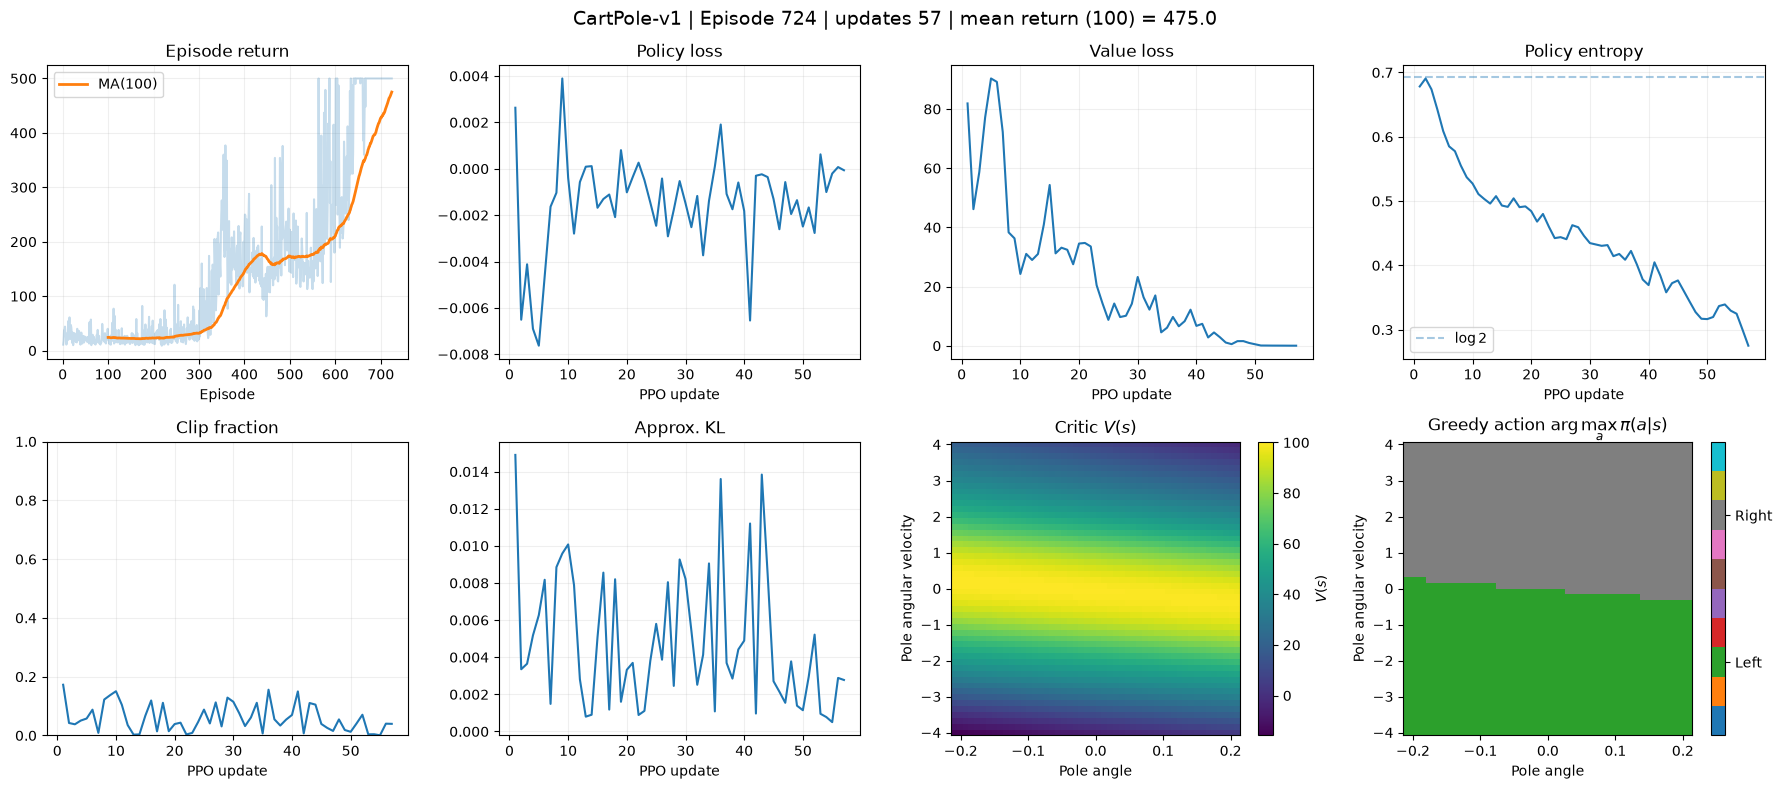

########## Принято! ##########
Episode 724, avg return = 475.0


In [24]:
env_name = "CartPole-v1"
# env_name = "MountainCar-v0"
# env_name = "LunarLander-v3"

env = gym.make(env_name)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

render = False

solved_reward = env.spec.reward_threshold
max_timesteps = env.spec.max_episode_steps

print("Environment:", env_name)
print("Observation dim:", state_dim)
print("Actions:", action_dim)
print("Max episode steps:", max_timesteps)
print("Reward threshold:", solved_reward)


state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

log_interval = 100
max_episodes = 50000

n_latent_var = 128
update_timestep = 2000

lr = 0.01
betas = (0.9, 0.999)

gamma = 0.99
gae_lambda = 0.95

K_epochs = 4
eps_clip = 0.2

vf_coef = 0.25
ent_coef = 0.01

random_seed = None


if random_seed is not None:
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    state, _ = env.reset(seed=random_seed)


memory = Memory()

ppo = PPO(
    state_dim,
    action_dim,
    n_latent_var,
    lr,
    betas,
    gamma,
    gae_lambda,
    K_epochs,
    eps_clip,
    vf_coef=vf_coef,
    ent_coef=ent_coef,
)

dashboard = LivePPODashboard(
    ppo,
    env_name=env_name,
    refresh_every=10,
    ma_window=100,
)

timestep = 0


for i_episode in range(1, max_episodes + 1):

    state, _ = env.reset()

    episode_return = 0.0

    for t in range(max_timesteps):

        timestep += 1

        action = ppo.policy_old(
            state,
            memory,
        )

        next_state, reward, terminated, truncated, _ = (
            env.step(action)
        )

        memory.next_states.append(
            torch.from_numpy(next_state)
            .float()
            .to(device)
        )

        memory.rewards.append(reward)
        memory.is_terminals.append(terminated)
        memory.is_truncateds.append(truncated)

        state = next_state
        episode_return += reward

        # PPO update
        if timestep >= update_timestep:

            stats = ppo.update(memory)

            dashboard.log_update(stats)

            memory.clear_memory()
            timestep = 0

        if terminated or truncated:
            break

    dashboard.log_episode(
        i_episode,
        episode_return,
        t + 1,
    )

    # CartPole-v1 solved check
    if len(dashboard.returns) >= log_interval:

        avg_reward = np.mean(
            dashboard.returns[-log_interval:]
        )

        if avg_reward >= solved_reward:
            dashboard.render()

            print(
                f"########## Принято! ##########\n"
                f"Episode {i_episode}, "
                f"avg return = {avg_reward:.1f}"
            )

            break


env.close()

# Визуализация

/Users/kurise/miniconda3/envs/scaner/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /Users/kurise/Projects/repos/SB-RL-2026/seminars/videos/CartPole-v1 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episode 1: return = 500.0, length = 500
Episode 2: return = 500.0, length = 500
Episode 3: return = 500.0, length = 500

Environment: CartPole-v1
Policy: deterministic
Mean return: 500.00 ± 0.00
Mean episode length: 500.0 ± 0.0


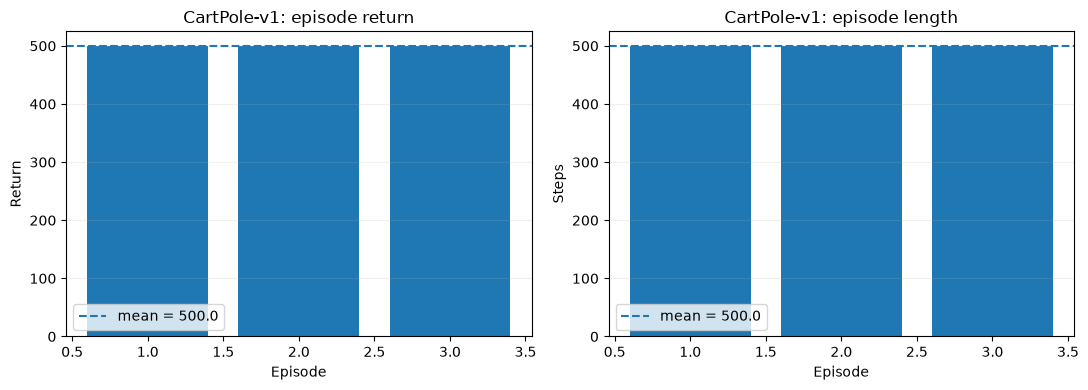

In [25]:
# 1. Посмотреть, чему научились actor и critic
visualize_ppo_policy(ppo, env_name, num_episodes=3, deterministic=True)